# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 46    |  |
| :-------------|:-------------|
| Oskar van Velze| 6044247 |
| Rune Veraart | 6439748 |
| Vera Reeringh | 6321046 |
| Planning Groep: 46     |Tijdstip / Tijdspanne  |
|---|---|
| Condensator af| 12:15 |
| Sensor af | 16: 15 |
| groep aanwezig 1| 10:45-12:30 |
| groep aanwezig 2| 13:30-17:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:15-16:30 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schets.jpeg" alt="schets student 1" width="400"/>

In [3]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon0 = 8.85*10**-12
A = 0.01
d=0.001
def capaciteit(epsilon_r, A, d):
    C_plaat = epsilon0 * epsilon_r * A/d *1e12
    return C_plaat

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [13]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = capaciteit(1, 1e-2, 1e-3)


print(f"Berekende capaciteit plaatcondensator groep 46 is {C:.1f} pF")



Berekende capaciteit plaatcondensator groep 46 is 88.5 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](condensator.jpeg)
![scope meting 2](scope.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 46| 88.5 pF | 0.44 V | 0.483 V |96.1 pF|

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](3.3%20woensdag%20toepassingen%20bedenken.jpg)


Schets 1 : $\epsilon_r$  verandering gebruiken voor meten gewicht


Schets 2: Oppervlakte verandering gebruiken voor meten waterpeil


Schets 3: dikte verandering gebruiken voor meten aantal mol lucht met n = P * V / R * T

## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die gewicht meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](tudelftLogo.png)

In [34]:
from scipy.optimize import curve_fit

g = 9.81 # valversnelling
def veerconstante(u,c,b):
    m = (u * c + b)/g
    return m


gewicht_array = np.array([646, 0, 486, 283.5, 143, 53.7, 316])*1e-3
x_array = np.array([38.3, 13.25, 32.5, 25.6, 19.8, 17.1, 26.5])*1e-2

popt, pcov = curve_fit(veerconstante, x_array, gewicht_array)
c = popt[0]
b = popt[1]

print ('c:', c, 'N/m')
print ('b:', b)


c: 25.971377836775243 N/m
b: -3.718261049236115


[0.         0.00264744 0.00529488 0.00794232 0.01058976 0.0132372
 0.01588463 0.01853207 0.02117951 0.02382695 0.02647439 0.02912183
 0.03176927 0.03441671 0.03706415 0.03971159 0.04235903 0.04500647
 0.0476539  0.05030134 0.05294878 0.05559622 0.05824366 0.0608911
 0.06353854 0.06618598 0.06883342 0.07148086 0.0741283  0.07677573
 0.07942317 0.08207061 0.08471805 0.08736549 0.09001293 0.09266037
 0.09530781 0.09795525 0.10060269 0.10325013 0.10589757 0.108545
 0.11119244 0.11383988 0.11648732 0.11913476 0.1217822  0.12442964
 0.12707708 0.12972452 0.13237196 0.1350194  0.13766683 0.14031427
 0.14296171 0.14560915 0.14825659 0.15090403 0.15355147 0.15619891
 0.15884635 0.16149379 0.16414123 0.16678867 0.1694361  0.17208354
 0.17473098 0.17737842 0.18002586 0.1826733  0.18532074 0.18796818
 0.19061562 0.19326306 0.1959105  0.19855793 0.20120537 0.20385281
 0.20650025 0.20914769 0.21179513 0.21444257 0.21709001 0.21973745
 0.22238489 0.22503233 0.22767976 0.2303272  0.23297464 0.23562208

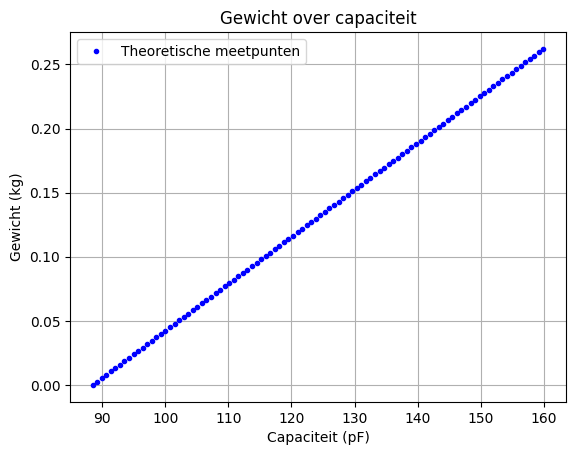

De minimale capaciteit is 88.5 pF
De maximale capaciteit is 159.9195 pF


In [38]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

import numpy as np
import matplotlib.pyplot as plt

# C = epsilon0*epsilonr * A/d
# C_lucht = 52.11, met Vout = 0.63V
# C_materiaal = 52.11 / 0.63 * 1.138 (1.138V is gemeten V_out met materiaal)
# C_materiaal = 94.1335979
# epsilonr = C*d/epsilon0 * A = 1.807

permitiviteit = 1.807

e_r = np.linspace(1,permitiviteit,100)
cap = capaciteit(e_r, 0.01, 0.001)

g = -9.81 # valversnelling
c_veer = c # gevonden veerconstante

def func_gewicht (u,c_veer):
    F = -c_veer * u
    m = F / g
    return m

u = np.arange(0,100,1) / 1000 # uitwijking in meter
gewicht =  func_gewicht(u, c)
print(gewicht)

plt.figure()
plt.title ( 'Gewicht over capaciteit')
plt.plot (cap, gewicht, 'b.', label = 'Theoretische meetpunten')
plt.xlabel('Capaciteit (pF)')
plt.ylabel ('Gewicht (kg)')
plt.legend()
plt.grid()
plt.show()

min_cap = np.min(cap) # theoretische minimale capaciteit
max_cap = np.max(cap) # theoretische minimale capaciteit

print ('De minimale capaciteit is', round(min_cap,4), 'pF')
print ('De maximale capaciteit is', round(max_cap,4), 'pF')

## Opdracht 5: Invullen tabel LTSpice.

![LTSpice](3.3%20LTSpice%20sims.png)

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 52 pF | 261.23 mV |
| gemiddelde capaciteit|425 pF | 2.05694 V |
| maximale capaciteit| 798 pF | 3.54933 V |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](tudelftLogo.png)
![meting 2](tudelftLogo.png)

## Opdracht 7: Plot de kalibratiegrafiek.

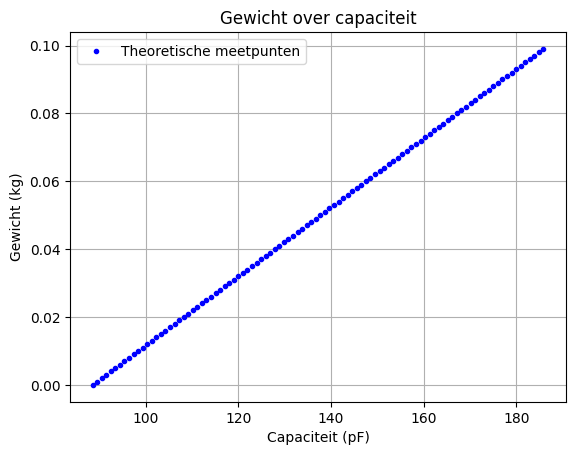

De minimale capaciteit is 88.5 pF
De maximale capaciteit is 185.85 pF


In [ ]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

import numpy as np
import matplotlib.pyplot as plt

gewicht_metingen = np.array([])
capaciteit_metingen = np.array ([])

g = -9.81 # valversnelling
u_0 = 0 # beginuitwijking
c_veer = c # veerconstante


plt.figure()
plt.title ( 'Capaciteit over gewict')
plt.plot (capaciteit_metingen, gewicht_metingen, 'r.', label = 'meetpunten')
plt.xlabel('Gewicht (kg)')
plt.ylabel ('Capaciteit (pF)')
plt.legend()
plt.grid()
plt.show()



## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1
* verbetering 2

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](tudelftLogo.png)

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

## Opdracht 10: Vul hieronder de conclusie in.

Vul hier de conclusie in

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.